# Entrega 1 — Análise comparativa de representações

**Ouvidoria Municipal — busca semântica de manifestações**

O corpus tem 40 manifestações de cidadãos distribuídas em cinco categorias oficiais.
Este notebook compara três formas de representar esses textos:

| Família | Representação | O que captura |
|---|---|---|
| Esparsa | **BoW** (contagem) | quais palavras aparecem e quantas vezes |
| Esparsa | **TF-IDF** | as mesmas palavras, ponderadas pela raridade no corpus |
| Densa | **Embeddings** (Sentence-BERT multilíngue) | o sentido da frase, mesmo sem palavras em comum |

A pergunta central é a do enunciado: **duas manifestações que relatam o mesmo problema
com palavras diferentes são reconhecidas como parecidas?** Os pares analisados são:

- `M003` × `M017` — *buraco enorme na Av. Brasil* × *asfalto todo esburacado da avenida principal* (**mesmo problema**)
- `M008` × `M022` — *posto de saúde sem médico* × *falta atendimento no PSF* (**mesmo problema**)
- `M008` × `M031` — *posto de saúde sem médico* × *lâmpada queimada na praça* (**problemas distintos**)

Um detector de duplicatas só é útil se os dois primeiros pares tiverem similaridade
**alta** e o terceiro, **baixa**.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from utils_ouvidoria import (
    STOPWORDS_PT,
    TINTA,
    carregar_corpus,
    cmap_sequencial,
    gerar_embeddings,
)

pd.set_option("display.max_colwidth", 80)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.color": TINTA["grade"],
    "axes.edgecolor": TINTA["grade"],
    "axes.labelcolor": TINTA["secundaria"],
    "text.color": TINTA["primaria"],
    "xtick.color": TINTA["suave"],
    "ytick.color": TINTA["suave"],
    "font.size": 9,
})

df = carregar_corpus()
textos = df.texto.tolist()
ids = df.id.tolist()
pos = {m: i for i, m in enumerate(ids)}

print(f"{len(df)} manifestações | {df.n_caracteres.min()}–{df.n_caracteres.max()} caracteres")
df.groupby("categoria").agg(
    manifestacoes=("id", "size"),
    media_caracteres=("n_caracteres", "mean"),
    textos_longos=("texto_longo", "sum"),
).round(1)

40 manifestações | 149–728 caracteres


,manifestacoes,media_caracteres,textos_longos
categoria,,,
educação,8,246.2,1
infraestrutura,8,166.9,0
meio ambiente,8,244.0,1
saúde,8,307.5,2
segurança,8,239.1,1


## 1. Representações esparsas

Tanto BoW quanto TF-IDF constroem um vetor por manifestação com **uma dimensão por
palavra do vocabulário**. A diferença está no peso: BoW usa a contagem bruta, TF-IDF
desconta os termos que aparecem em muitos documentos.

Geramos quatro variantes esparsas — com e sem remoção de *stopwords* — para separar
duas causas possíveis de erro: a representação em si e o ruído das palavras funcionais
(*de*, *que*, *está*, *não*), que são as mais frequentes do português.

In [2]:
configs = {
    "BoW": CountVectorizer(),
    "BoW s/ stopwords": CountVectorizer(stop_words=STOPWORDS_PT),
    "TF-IDF": TfidfVectorizer(),
    "TF-IDF s/ stopwords": TfidfVectorizer(stop_words=STOPWORDS_PT),
}

esparsas = {}
for nome, vec in configs.items():
    X = vec.fit_transform(textos)
    esparsas[nome] = {"X": X, "vec": vec, "sim": cosine_similarity(X)}

pd.DataFrame([
    {
        "representação": nome,
        "dimensões": d["X"].shape[1],
        "não-zeros por doc": round(d["X"].nnz / d["X"].shape[0], 1),
        "esparsidade": f"{100 * (1 - d['X'].nnz / np.prod(d['X'].shape)):.1f}%",
    }
    for nome, d in esparsas.items()
])

,representação,dimensões,não-zeros por doc,esparsidade
0,BoW,702,33.3,95.3%
1,BoW s/ stopwords,645,23.5,96.4%
2,TF-IDF,702,33.3,95.3%
3,TF-IDF s/ stopwords,645,23.5,96.4%


Cada manifestação ocupa cerca de 25 posições de um vetor de ~700 dimensões: **mais de
96% de cada vetor é zero**. Duas manifestações só chegam a ter similaridade de cosseno
diferente de zero se compartilharem literalmente a mesma palavra — é essa a restrição
que vai explicar todos os resultados abaixo.

In [3]:
# Quais termos o TF-IDF considera mais característicos de cada manifestação do par M003 × M017?
def termos_mais_pesados(mid, nome="TF-IDF", k=8):
    d = esparsas[nome]
    vocab = np.array(d["vec"].get_feature_names_out())
    linha = d["X"][pos[mid]].toarray().ravel()
    top = linha.argsort()[::-1][:k]
    return pd.Series(linha[top].round(3), index=vocab[top], name=mid)

pd.concat([termos_mais_pesados("M003"), termos_mais_pesados("M017")], axis=1).fillna("—")

,M003,M017
buraco,0.405,—
carro,0.202,—
altura,0.202,—
1200,0.202,—
veio,0.202,—
consertar,0.202,—
av,0.202,—
pneus,0.202,—
para,—,0.368
esburacado,—,0.238


In [4]:
analisador = esparsas["TF-IDF"]["vec"].build_analyzer()

def sobreposicao(a, b):
    ta, tb = set(analisador(df.texto[pos[a]])), set(analisador(df.texto[pos[b]]))
    comuns = sorted(ta & tb)
    return {
        "par": f"{a} × {b}",
        "termos em comum": len(comuns),
        "jaccard": round(len(comuns) / len(ta | tb), 3),
        "quais": ", ".join(comuns),
    }

pd.DataFrame([sobreposicao("M003", "M017"), sobreposicao("M008", "M022"), sobreposicao("M008", "M031")])

,par,termos em comum,jaccard,quais
0,M003 × M017,4,0.083,"da, equipe, está, nenhuma"
1,M008 × M022,4,0.082,"atendimento, da, de, pronto"
2,M008 × M031,6,0.140,"as, bairro, da, de, do, está"


Esse quadro é o diagnóstico do problema. O par `M008` × `M031`, que trata de **assuntos
completamente diferentes** (falta de médico × lâmpada queimada), compartilha *mais*
palavras do que o par `M003` × `M017`, que relata **o mesmo buraco na mesma avenida**.

O motivo é que as palavras em comum de `M008` × `M031` são funcionais (*a*, *de*, *da*,
*está*, *no*), enquanto `M003` e `M017` descrevem o mesmo fato com vocabulário
disjunto: *buraco* × *esburacado*, *Av. Brasil* × *avenida principal*, *consertar* ×
*tapar*. Nenhum modelo baseado em contagem de palavras consegue ligar esses termos.

## 2. Representações densas (embeddings)

Um modelo Sentence-BERT projeta cada manifestação inteira em um vetor denso de algumas
centenas de dimensões, treinado para que **frases com o mesmo sentido fiquem próximas**,
mesmo sem palavras em comum.

Comparamos dois modelos multilíngues. O enunciado sugere `BAAI/bge-small-pt-v1.5`, mas
esse repositório **não existe no HuggingFace Hub** (retorna 404), então o segundo modelo
é o `paraphrase-multilingual-mpnet-base-v2`, maior e mais preciso.

In [5]:
MODELOS_COMPARADOS = [
    "paraphrase-multilingual-MiniLM-L12-v2",
    "paraphrase-multilingual-mpnet-base-v2",
]

densas = {}
for nome in MODELOS_COMPARADOS:
    inicio = time.perf_counter()
    E = gerar_embeddings(textos, nome)
    densas[nome] = {"X": E, "sim": cosine_similarity(E), "tempo": time.perf_counter() - inicio}
    print(f"{nome:42s} dim={E.shape[1]:4d}  {densas[nome]['tempo']:.1f}s para 40 textos")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

paraphrase-multilingual-MiniLM-L12-v2      dim= 384  8.3s para 40 textos


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

paraphrase-multilingual-mpnet-base-v2      dim= 768  7.0s para 40 textos


Note a diferença estrutural: os vetores densos têm 384 e 768 dimensões **todas
preenchidas**, contra ~700 dimensões 96% vazias das representações esparsas. A
informação deixa de ser "quais palavras" e passa a ser "qual sentido".

## 3. Os três pares do enunciado

Comparação lado a lado de todas as representações.

In [6]:
PARES = [
    ("M003", "M017", "mesmo problema", "buraco na Av. Brasil × asfalto esburacado"),
    ("M008", "M022", "mesmo problema", "posto sem médico × falta atendimento no PSF"),
    ("M008", "M031", "problemas distintos", "posto sem médico × lâmpada queimada na praça"),
]

todas = {**esparsas, **densas}
linhas = []
for a, b, relacao, descricao in PARES:
    linha = {"par": f"{a} × {b}", "relação esperada": relacao, "descrição": descricao}
    for nome, d in todas.items():
        linha[nome] = round(float(d["sim"][pos[a], pos[b]]), 3)
    linhas.append(linha)

tabela = pd.DataFrame(linhas)
colunas_sim = list(todas.keys())
tabela.style.background_gradient(cmap=cmap_sequencial(), subset=colunas_sim, vmin=0, vmax=1).format(
    {c: "{:.3f}" for c in colunas_sim}
)

,par,relação esperada,descrição,BoW,BoW s/ stopwords,TF-IDF,TF-IDF s/ stopwords,paraphrase-multilingual-MiniLM-L12-v2,paraphrase-multilingual-mpnet-base-v2
0,M003 × M017,mesmo problema,buraco na Av. Brasil × asfalto esburacado,0.117,0.104,0.065,0.064,0.579,0.734
1,M008 × M022,mesmo problema,posto sem médico × falta atendimento no PSF,0.207,0.143,0.118,0.117,0.721,0.642
2,M008 × M031,problemas distintos,posto sem médico × lâmpada queimada na praça,0.316,0.050,0.113,0.027,0.240,0.372


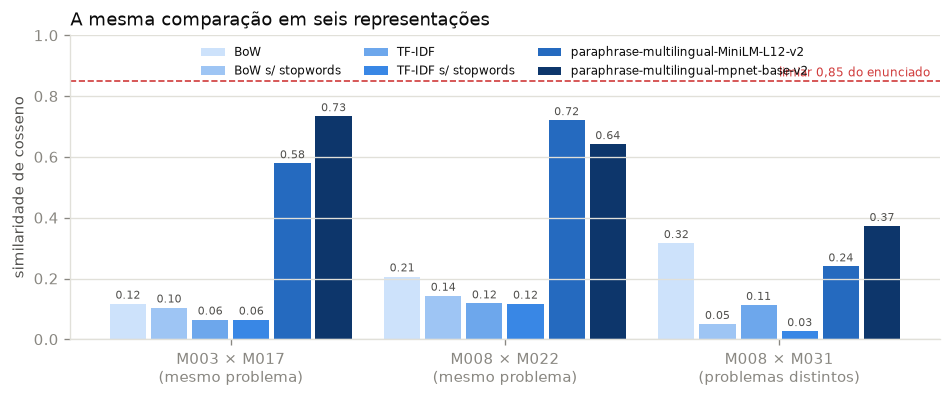

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.4))

rotulos = [f"{a} × {b}" for a, b, _, _ in PARES]
x = np.arange(len(PARES))
largura = 0.15
cores = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#0d366b"]

for i, (nome, d) in enumerate(todas.items()):
    valores = [d["sim"][pos[a], pos[b]] for a, b, _, _ in PARES]
    barras = ax.bar(x + (i - 2.5) * largura, valores, largura * 0.88, label=nome, color=cores[i])
    ax.bar_label(barras, fmt="%.2f", fontsize=6.5, padding=1.5, color=TINTA["secundaria"])

ax.axhline(0.85, color="#d03b3b", lw=1, ls="--")
ax.text(len(PARES) - 0.45, 0.865, "limiar 0,85 do enunciado", fontsize=7, color="#d03b3b", ha="right")
ax.set_xticks(x)
ax.set_xticklabels([f"{r}\n({p[2]})" for r, p in zip(rotulos, PARES)])
ax.set_ylabel("similaridade de cosseno")
ax.set_ylim(0, 1)
ax.set_title("A mesma comparação em seis representações", loc="left", fontsize=11, color=TINTA["primaria"])
ax.legend(fontsize=7, ncol=3, loc="upper center", frameon=False)
ax.grid(axis="x", visible=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Leitura par a par

**`M003` × `M017` — o mesmo buraco, descrito de duas formas.** É o caso mais severo.
Em BoW a similaridade fica em 0,117 e em TF-IDF cai para 0,065. Os embeddings colocam o
par em 0,58 (MiniLM) e 0,73 (mpnet). Só a representação densa enxerga que *buraco* e
*esburacado*, *Av. Brasil* e *avenida principal* falam da mesma coisa.

Vale observar o que a remoção de stopwords faz — e o que ela **não** faz. Para este par
o valor mal se move (0,117 → 0,104 em BoW): as quatro palavras em comum eram *da*,
*equipe*, *está* e *nenhuma*, e tirar as funcionais apenas encolhe proporcionalmente
numerador e denominador. Limpar o vocabulário **não cria** a similaridade que falta,
porque não existe nenhuma palavra de conteúdo compartilhada para ser encontrada.

**`M008` × `M022` — posto sem médico × falta de atendimento no PSF.** Mesma história com
um agravante de domínio: "PSF" (Programa Saúde da Família) é sinônimo institucional de
"posto de saúde", mas são strings diferentes. TF-IDF dá ~0,12; os embeddings dão 0,72
(MiniLM), o valor mais alto entre os três pares — o modelo reconhece o vínculo mesmo
sem nenhuma pista lexical.

**`M008` × `M031` — o par que deveria ser baixo.** Aqui está o erro mais grave das
representações esparsas: em BoW o par **não relacionado** marca 0,316, quase **três
vezes** o valor de 0,117 do par que é duplicata real. Um sistema de ouvidoria que usasse
BoW agruparia "falta de médico" com "lâmpada queimada" antes de agrupar duas denúncias
do mesmo buraco. Os embeddings colocam esse par em 0,24, abaixo dos dois anteriores — a
ordem correta.

É justamente neste par que a remoção de stopwords funciona: o valor despenca de 0,316
para 0,050 em BoW, porque quase tudo que unia as duas manifestações era palavra
funcional. O resultado combinado é instrutivo — **a limpeza de vocabulário corrige o
falso positivo, mas é incapaz de corrigir o falso negativo.** Depois de remover
stopwords, o par duplicado (0,104) e o par não relacionado (0,050) ficam ambos rentes ao
chão, na mesma faixa indistinguível.

### O impacto prático: uma busca do cidadão

O teste decisivo não é a similaridade de um par isolado, e sim o **ranking** devolvido
quando alguém digita uma descrição livre — que é exatamente o caso de uso do app da
Entrega 4.

In [8]:
CONSULTA = "não tem médico atendendo no posto do meu bairro"

resultados = {}
for nome, d in esparsas.items():
    q = d["vec"].transform([CONSULTA])
    resultados[nome] = cosine_similarity(q, d["X"]).ravel()
for nome in MODELOS_COMPARADOS:
    q = gerar_embeddings([CONSULTA], nome)
    resultados[nome] = cosine_similarity(q, densas[nome]["X"]).ravel()

TOP = 3
saida = []
for nome, scores in resultados.items():
    for rank, i in enumerate(scores.argsort()[::-1][:TOP], start=1):
        saida.append({
            "representação": nome,
            "posição": rank,
            "id": ids[i],
            "score": round(float(scores[i]), 3),
            "categoria": df.categoria[i],
            "trecho": textos[i][:60] + "...",
        })

pd.DataFrame(saida).set_index(["representação", "posição"])

id  score      categoria  \
representação                         posição                               
BoW                                   1        M021  0.396       educação   
                                      2        M008  0.291          saúde   
                                      3        M020  0.208      segurança   
BoW s/ stopwords                      1        M008  0.369          saúde   
                                      2        M020  0.289      segurança   
                                      3        M015  0.140  meio ambiente   
TF-IDF                                1        M021  0.283       educação   
                                      2        M008  0.273          saúde   
                                      3        M020  0.178      segurança   
TF-IDF s/ stopwords                   1        M008  0.345          saúde   
                                      2        M020  0.230      segurança   
                                      3        M038  0.124          saúde   
paraphrase-multilingual-MiniLM-L12-v2 1        M008  0.679          saúde   
                                      2        M022  0.544          saúde   
                                      3        M002  0.534          saúde   
paraphrase-multilingual-mpnet-base-v2 1        M008  0.603          saúde   
                                      2        M022  0.577          saúde   
                                      3        M002  0.507          saúde   

                                                                                                        trecho  
representação                         posição                                                                   
BoW                                   1        A creche municipal do bairro Esperança não tem vaga para cri...  
                                      2        O posto de saúde do bairro São José está sem médico desde o ...  
                                      3        A praça do bairro Industrial ficou sem ronda da guarda munic...  
BoW s/ stopwords                      1        O posto de saúde do bairro São José está sem médico desde o ...  
                                      2        A praça do bairro Industrial ficou sem ronda da guarda munic...  
                                      3        A coleta seletiva não passa no bairro Vila Nova há quase um ...  
TF-IDF                                1        A creche municipal do bairro Esperança não tem vaga para cri...  
                                      2        O posto de saúde do bairro São José está sem médico desde o ...  
                                      3        A praça do bairro Industrial ficou sem ronda da guarda munic...  
TF-IDF s/ stopwords                   1        O posto de saúde do bairro São José está sem médico desde o ...  
                                      2        A praça do bairro Industrial ficou sem ronda da guarda munic...  
                                      3        Os remédios estão em falta na farmácia do posto de saúde. Us...  
paraphrase-multilingual-MiniLM-L12-v2 1        O posto de saúde do bairro São José está sem médico desde o ...  
                                      2        Falta atendimento no PSF da minha região. Não tem clínico ge...  
                                      3        Marquei consulta com o cardiologista pelo sistema da prefeit...  
paraphrase-multilingual-mpnet-base-v2 1        O posto de saúde do bairro São José está sem médico desde o ...  
                                      2        Falta atendimento no PSF da minha região. Não tem clínico ge...  
                                      3        Marquei consulta com o cardiologista pelo sistema da prefeit...

O ranking expõe o problema melhor que qualquer par isolado. A consulta contém
literalmente as palavras "médico" e "posto", ou seja, é o **caso mais favorável
possível** para as representações esparsas — e ainda assim BoW coloca em primeiro lugar
`M021`, uma manifestação sobre **falta de vaga em creche**, à frente de `M008`. O que a
colocou lá foram coincidências funcionais ("não tem ... no meu/minha ..."), não o
assunto.

Mais grave: **nenhuma das quatro variantes esparsas recupera `M022`** entre as três
primeiras, embora `M022` relate exatamente o mesmo problema da consulta — só que com as
palavras "PSF" e "clínico geral". Para a ouvidoria isso significa que a manifestação
duplicada não apareceria para o atendente, e o mesmo problema seria protocolado duas
vezes.

Os dois modelos de embedding devolvem `M008` e `M022` nas duas primeiras posições, e em
terceiro `M002` — outra manifestação de saúde sobre demora de atendimento. O ranking
inteiro fica dentro do assunto certo.

### Separabilidade no corpus inteiro

Ampliando dos 3 pares do enunciado para os 780 pares possíveis: uma boa representação
deve manter as 6 duplicatas reais do corpus acima da nuvem dos demais pares.

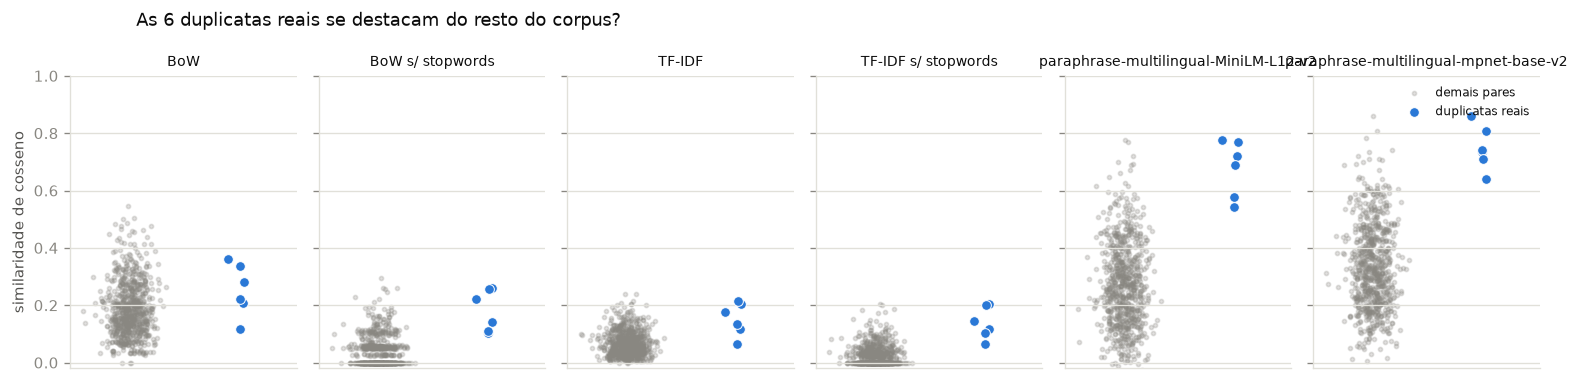

,representação,média das duplicatas,média dos demais pares,razão
0,BoW,0.255,0.188,1.36
1,BoW s/ stopwords,0.183,0.037,4.90
2,TF-IDF,0.153,0.068,2.25
3,TF-IDF s/ stopwords,0.139,0.024,5.84
4,paraphrase-multilingual-MiniLM-L12-v2,0.680,0.268,2.54
5,paraphrase-multilingual-mpnet-base-v2,0.749,0.333,2.25


In [9]:
from utils_ouvidoria import carregar_gabarito

gabarito = carregar_gabarito()
duplicatas_reais = [(r.id_a, r.id_b) for r in gabarito[gabarito.relacao == "duplicata"].itertuples()]

fig, axes = plt.subplots(1, len(todas), figsize=(13, 3.2), sharey=True)
i_sup, j_sup = np.triu_indices(len(ids), k=1)

for ax, (nome, d) in zip(axes, todas.items()):
    S = d["sim"]
    todos = S[i_sup, j_sup]
    dups = np.array([S[pos[a], pos[b]] for a, b in duplicatas_reais])
    ax.scatter(np.random.default_rng(0).normal(0, 0.05, len(todos)), todos,
               s=6, alpha=0.25, color=TINTA["suave"], label="demais pares", zorder=1)
    ax.scatter(np.random.default_rng(1).normal(0.45, 0.03, len(dups)), dups,
               s=34, color="#2a78d6", edgecolor="white", linewidth=0.6,
               label="duplicatas reais", zorder=3)
    ax.set_title(nome, fontsize=8.5, color=TINTA["primaria"])
    ax.set_xticks([])
    ax.set_xlim(-0.25, 0.7)
    ax.set_ylim(-0.02, 1)
    ax.grid(axis="x", visible=False)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("similaridade de cosseno")
axes[-1].legend(fontsize=7, frameon=False, loc="upper right")
fig.suptitle("As 6 duplicatas reais se destacam do resto do corpus?", x=0.09, ha="left", fontsize=11)
plt.tight_layout()
plt.show()

pd.DataFrame([
    {
        "representação": nome,
        "média das duplicatas": round(float(np.mean([d["sim"][pos[a], pos[b]] for a, b in duplicatas_reais])), 3),
        "média dos demais pares": round(float(d["sim"][i_sup, j_sup].mean()), 3),
        "razão": round(float(np.mean([d["sim"][pos[a], pos[b]] for a, b in duplicatas_reais]) / d["sim"][i_sup, j_sup].mean()), 2),
    }
    for nome, d in todas.items()
])

**Cuidado ao ler a coluna "razão".** Ela é a maior justamente nas representações mais
fracas: TF-IDF sem stopwords atinge 5,8 contra 2,5 do MiniLM. Isso **não** significa que
o TF-IDF separe melhor — significa que o denominador colapsou. A média dos pares comuns
cai para 0,024, então qualquer valor ligeiramente acima de zero produz uma razão grande,
enquanto as duplicatas reais permanecem em 0,14 em termos absolutos, valor baixo demais
para sustentar qualquer limiar.

O que importa operacionalmente é a **distância absoluta entre as duas nuvens** do
gráfico acima: com embeddings as duplicatas reais ficam entre 0,54 e 0,86, numa faixa
onde um corte é possível; com TF-IDF elas ficam entre 0,065 e 0,215, dentro do mesmo
intervalo ocupado por centenas de pares sem nenhuma relação. É esse critério — e não a
razão entre médias — que a Entrega 2 usa para calibrar o limiar.

## Conclusão — limitações de cada abordagem

**BoW** trata a manifestação como um saco de palavras: perde a ordem, a negação e
qualquer noção de sinônimo, e ainda é dominado pelas palavras mais frequentes do
português. O resultado prático no corpus da ouvidoria é o pior possível — o par não
relacionado `M008` × `M031` recebe similaridade quase três vezes maior que a duplicata
real `M003` × `M017`, porque "estar sem alguma coisa" é dito com as mesmas palavras
funcionais em qualquer denúncia. É uma representação que mede **estilo de escrita**,
não assunto.

**TF-IDF** corrige parte disso ao penalizar termos comuns, e de fato reordena o par não
relacionado para baixo. Mas a correção é sobre o *peso* das palavras, não sobre o
*significado* delas: a métrica continua exigindo que as duas manifestações usem a mesma
string. Como o efeito do IDF é justamente reduzir o peso do vocabulário compartilhado,
os valores absolutos despencam e **todos** os pares ficam próximos de zero — as
duplicatas reais do corpus ficam entre 0,065 e 0,215, longe de qualquer limiar utilizável.
Some-se a isso a sensibilidade a flexão e grafia (*buraco*/*esburacado*, *médico*/*PSF*
são tipos distintos) e o fato de o vocabulário ser fechado: uma palavra que o cidadão
digitar e não existir no corpus simplesmente não tem dimensão.

**Embeddings** resolvem o problema central — reconhecem paráfrase sem palavras em comum
e preservam a ordem correta entre os três pares — mas não são um oráculo. Três
limitações aparecem já neste corpus pequeno: (i) a escala não é absoluta, e 0,58 aqui
significa "mesmo problema" enquanto no mesmo modelo 0,70 pode significar apenas "mesmo
assunto", o que torna qualquer limiar fixo dependente do modelo (o limiar de 0,85 do
enunciado não capturaria **nenhuma** das duplicatas reais com o MiniLM); (ii) o modelo
captura o *tema* e tende a ignorar o que distingue duas denúncias de um mesmo tipo —
"poste apagado na Rua das Acácias" e "lâmpada queimada na praça" são problemas
diferentes, em locais diferentes, e ficam com similaridade alta, o que é a origem dos
falsos positivos investigados na Entrega 2; e (iii) há custo computacional e dependência
de um modelo pré-treinado externo, cujo comportamento em português varia — o
`multilingual-e5-small`, por exemplo, comprime todas as similaridades acima de 0,85 e
fica inútil para thresholding, enquanto o `mpnet` custa o dobro do tempo do `MiniLM`.

**Consequência para o projeto:** as entregas seguintes usam embeddings como
representação de trabalho, mas nenhum limiar é adotado como constante universal — a
Entrega 2 calibra o corte a partir da própria distribuição de similaridades do corpus.